## K-Means Customer Segmentation

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
sns.set_style('whitegrid')

In [3]:
rfm = pd.read_csv(
    r"../data/processed/rfm_dataset.csv"
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,2,8,4921.53,4,3,4,434,Loyal Customers
1,75,5,2019.40,3,3,3,333,Potential Loyalists
2,19,5,4404.54,4,3,4,434,Loyal Customers
3,310,1,334.40,2,1,2,212,Potential Loyalists
4,375,1,300.93,2,1,1,211,Potential Loyalists


In [4]:
# Select Features

rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
]

rfm_features.head()

,Recency,Frequency,Monetary
0,2,8,4921.53
1,75,5,2019.40
2,19,5,4404.54
3,310,1,334.40
4,375,1,300.93


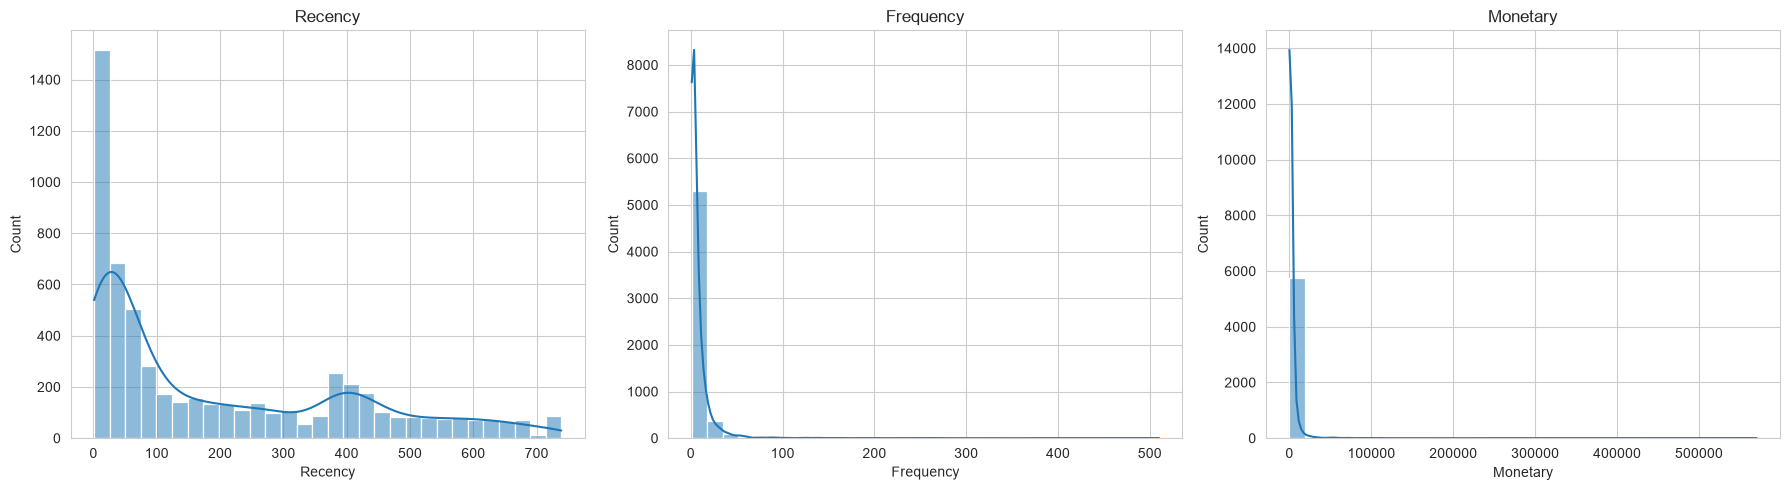

In [5]:
# Check Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, rfm_features.columns):

    sns.histplot(
        rfm_features[col],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

In [6]:
# Verify skewness

rfm_features.skew()

Recency       0.911089
Frequency    12.599493
Monetary     26.648326
dtype: float64

In [7]:
# Apply Log Transformation

rfm_log = rfm_features.copy()

rfm_log = np.log1p(rfm_log)

rfm_log.head()

,Recency,Frequency,Monetary
0,1.098612,2.197225,8.501578
1,4.330733,1.791759,7.611051
2,2.995732,1.791759,8.390618
3,5.739793,0.693147,5.815324
4,5.929589,0.693147,5.710195


In [8]:
# Compare Before and After

rfm_log.skew()

Recency     -0.474212
Frequency    0.884141
Monetary     0.200697
dtype: float64

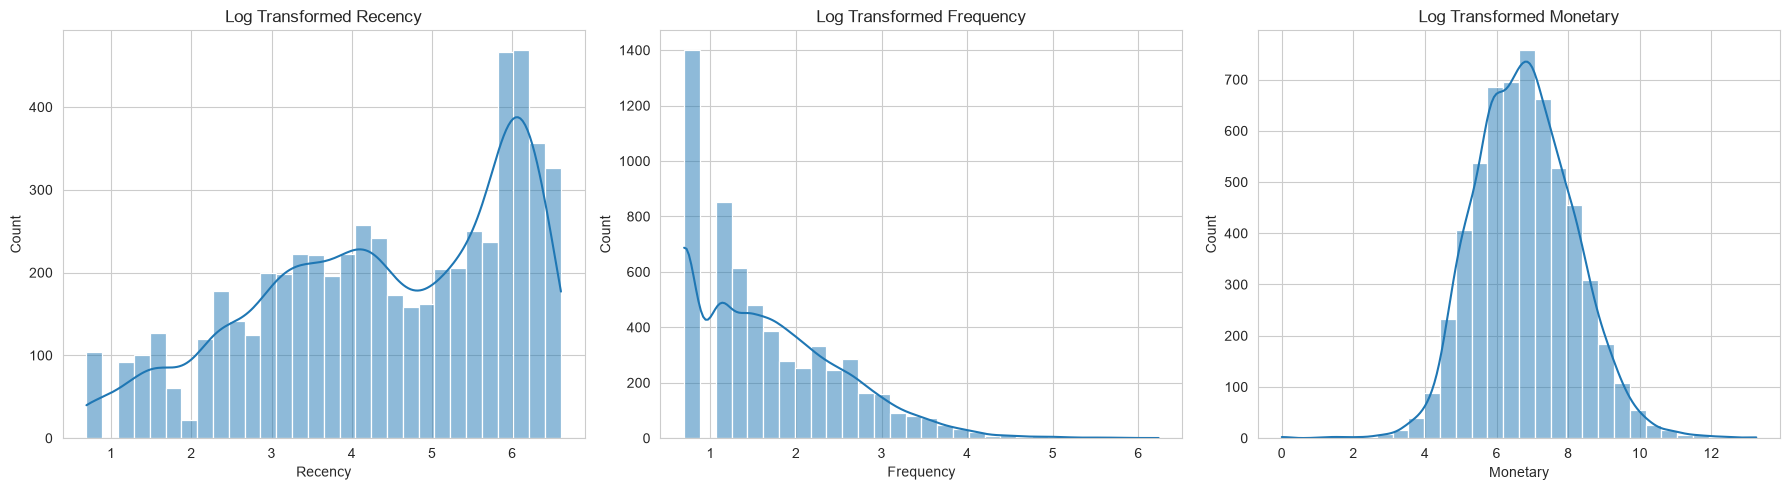

In [9]:
# Visualize Again

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, rfm_log.columns):
    sns.histplot(
        rfm_log[col],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Log Transformed {col}")

plt.tight_layout()

1. Evaluated the distribution of Recency, Frequency, and Monetary features using histograms and skewness.

2. Identified that Frequency and Monetary were extremely right-skewed, while Recency was moderately right-skewed.

3. Applied a logarithmic transformation using np.log1p() to reduce skewness while safely handling zero values.

4. Successfully reduced feature skewness, resulting in more balanced distributions suitable for distance-based clustering algorithms.

5. Preserved customer ordering while minimizing the influence of extreme spending and purchase frequency values.

6. Prepared the transformed features for standardization before applying the K-Means clustering algorithm.

In [10]:
# Create Scaler

scaler = StandardScaler()

In [11]:
# Fit and Transform

rfm_scaled = scaler.fit_transform(rfm_log)

In [12]:
# Convert Back to DataFrame

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,-2.091547,0.609319,1.239219
1,-0.050152,0.141675,0.594541
2,-0.893334,0.141675,1.158892
3,0.839804,-1.125411,-0.705437
4,0.959679,-1.125411,-0.781543


In [13]:
# Check Mean

rfm_scaled.mean()

Recency     -1.800690e-16
Frequency   -2.676702e-17
Monetary     8.760116e-17
dtype: float64

In [14]:
# Check Standard Deviation

rfm_scaled.std()

Recency      1.000086
Frequency    1.000086
Monetary     1.000086
dtype: float64

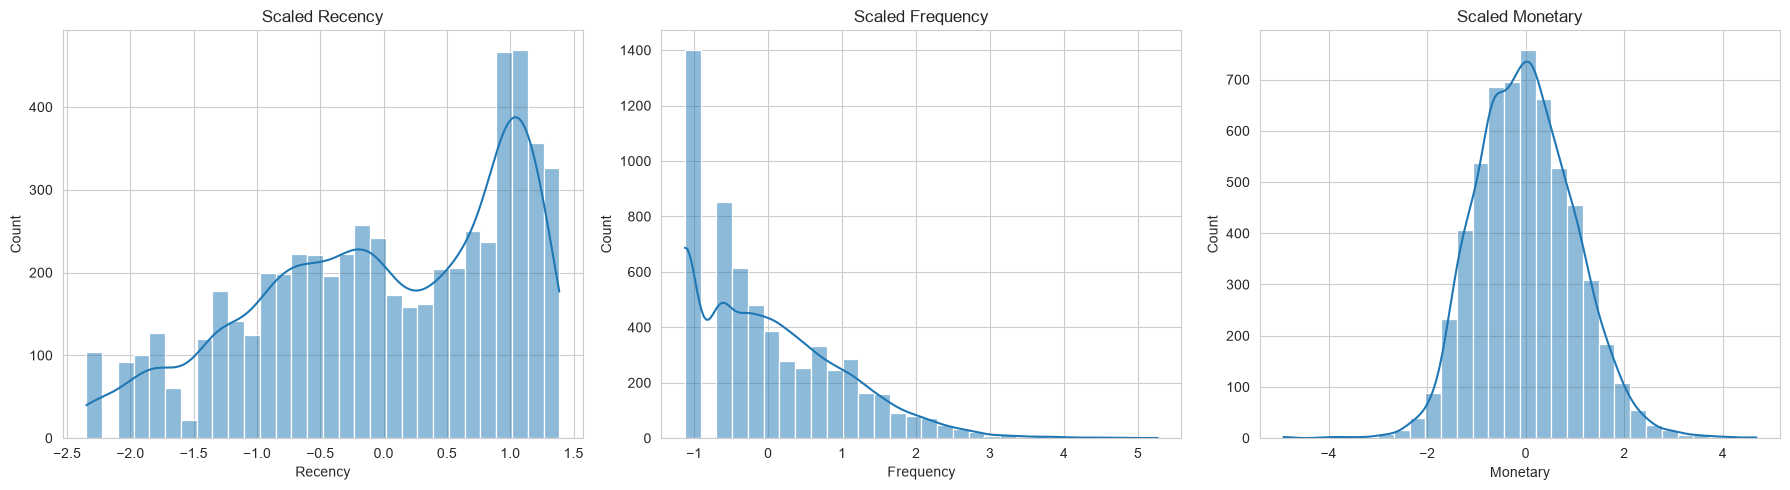

In [15]:
# Visualize

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, rfm_scaled.columns):

    sns.histplot(
        rfm_scaled[col],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Scaled {col}")

plt.tight_layout()

1. Applied StandardScaler to the log-transformed RFM features.

2. Standardized each feature to have an approximate mean of zero and a standard deviation of one.

3. Verified the scaling process by examining feature statistics and visualizing the transformed distributions.

4. Ensured that Recency, Frequency, and Monetary contribute equally to Euclidean distance calculations.

5. Prepared the standardized dataset for determining the optimal number of clusters using the Elbow Method and Silhouette Score.

In [ ]:
# Elbow Method

wcss = []

for k in range(2, 11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

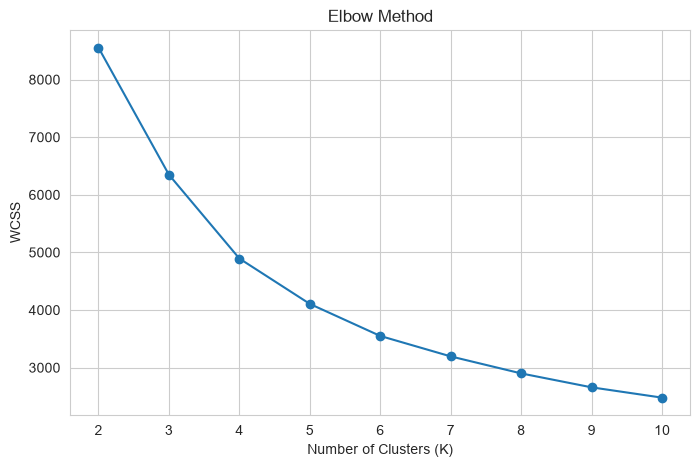

In [ ]:
# Plot the Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

In [ ]:
# Calculate Silhouette Scores

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

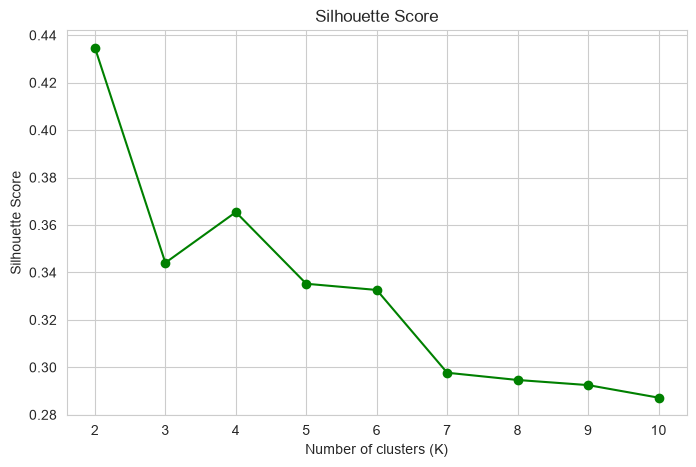

In [ ]:
# Plot Silhouette Scores

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o',
    color='green'
)

plt.title("Silhouette Score")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

In [ ]:
# Compare Both Methods

evaluation = pd.DataFrame({
    "K": range(2,11),
    "WCSS": wcss,
    "Silhoutte Score": silhouette_scores
})

evaluation

,K,WCSS,Silhoutte Score
0,2,8553.537439,0.434752
1,3,6347.868988,0.344057
2,4,4893.116577,0.365410
3,5,4105.677796,0.335213
4,6,3549.425952,0.332599
5,7,3194.620994,0.297700
6,8,2899.424202,0.294645
7,9,2657.722538,0.292491
8,10,2478.856013,0.287195


1. Evaluated cluster compactness using the Elbow Method by calculating WCSS for K values ranging from 2 to 10.

2. Assessed clustering quality using the Silhouette Score to measure cluster cohesion and separation.

3. Observed that the Elbow Method suggested an optimal range around K = 4, where improvements in WCSS began to diminish.

4. Although K = 2 achieved the highest Silhouette Score, it produced overly broad customer groups that lacked sufficient business value.

5. Selected K = 4 as the optimal number of clusters because it balanced statistical performance with business interpretability and enabled meaningful customer segmentation.

In [30]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

In [31]:
rfm["Clusters"] = clusters

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Clusters
0,2,8,4921.53,4,3,4,434,Loyal Customers,1
1,75,5,2019.40,3,3,3,333,Potential Loyalists,2
2,19,5,4404.54,4,3,4,434,Loyal Customers,1
3,310,1,334.40,2,1,2,212,Potential Loyalists,0
4,375,1,300.93,2,1,1,211,Potential Loyalists,0


In [32]:
rfm["Clusters"].value_counts().sort_index()

Clusters
0    1994
1    1136
2    1462
3    1248
Name: count, dtype: int64

C:\Users\MUHAMMAD ADNAN\AppData\Local\Temp\ipykernel_9340\318073784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Number of Customers')

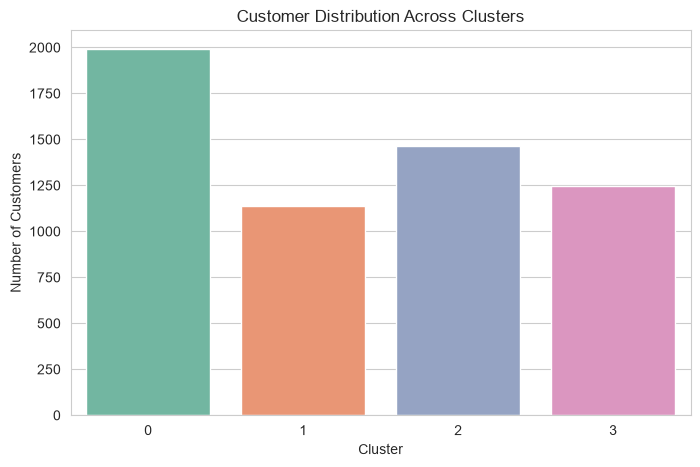

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Clusters",
    palette="Set2"
)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

In [35]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=rfm_scaled.columns
)

centroids

,Recency,Frequency,Monetary
0,0.877027,-0.882221,-0.919076
1,-1.125024,1.501531,1.352779
2,0.426449,0.303478,0.399219
3,-0.880358,-0.307951,-0.225895


In [36]:
cluster_profile = rfm.groupby("Clusters").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Clusters,,,
0,390.34,1.58,325.25
1,23.85,24.30,10494.38
2,214.19,6.54,1901.69
3,27.26,3.48,827.08


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

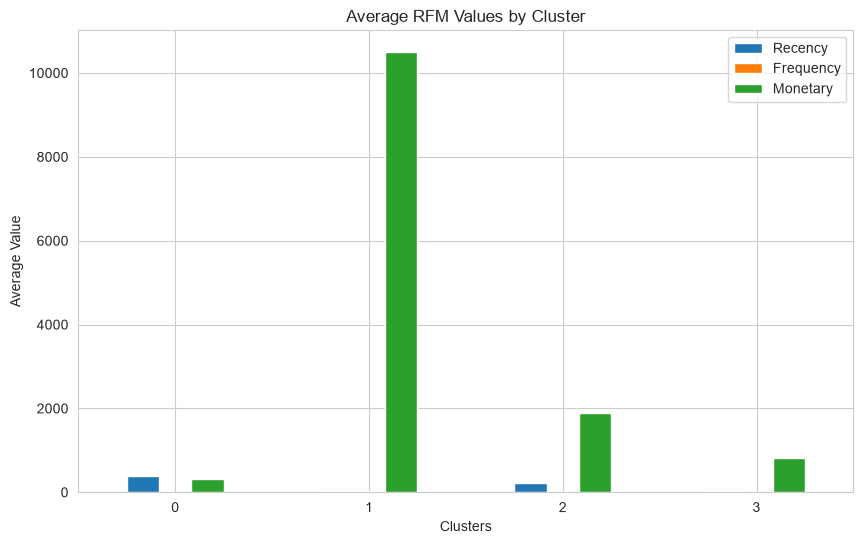

In [37]:
cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average RFM Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

1. Trained the final K-Means clustering model using the optimal value of K determined through the Elbow Method and Silhouette Score.

2. Assigned each customer to one of four clusters based on standardized RFM features.

3. Profiled each cluster using average Recency, Frequency, and Monetary values.

4. Assigned meaningful business names to each cluster, including Champions, Loyal Customers, Potential Loyalists, and At-Risk Customers.

5. Compared machine learning-based customer segments with rule-based RFM segments to validate the segmentation approach.

6. Developed business recommendations for each customer segment to support targeted marketing, retention, and revenue growth initiatives.